# Brain Connectivity & GNNs for Autism Classification

Today, you'll explore how to use machine learning to predict autism spectrum disorder (ASD) from resting-state fMRI data. We will build two types of models: a classical machine learning model (SVM) based on functional connectivity, and a more advanced Graph Neural Network (GNN) model.

Don't forget to select the runtime type of this notebook to GPU.

First, let's install and import all the necessary libraries. We'll be using `nilearn` for neuroimaging data, `scikit-learn` for classical ML, and `PyTorch` with `torch_geometric` for the GNN.

In [ ]:
# Install necessary packages
!pip install nilearn
!pip install torch_geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 53.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.5 MB/s eta 0:00:00


In [ ]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets, connectome, plotting
from nilearn.maskers import NiftiLabelsMasker
from nilearn.image import index_img
from nilearn.connectome import ConnectivityMeasure
from nilearn.plotting import plot_connectome, plot_matrix, find_parcellation_cut_coords

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, balanced_accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader, Dataset
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.utils import to_dense_adj

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


# Exercise 0: Autism and the ABIDE Dataset

Autism spectrum disorder (ASD) is characterised by qualitative impairment in social reciprocity, and by repetitive, restricted, and stereotyped behaviours/interests. Previously considered rare, ASD is now recognized to occur in more than 1% of children. The Autism Brain Imaging Data Exchange (ABIDE) dataset, which you'll be using today, includes functional and structural brain imaging data collected from laboratories around the world to accelerate our understanding of the neural bases of autism.


`nilearn` provides a convenient function to fetch a preprocessed version of this dataset, previously preprocessed by the **Preprocessed Connectomes Project (PCP)**.

The cell below will load 500 subjects from the ABIDE dataset; you can select more but I suggest you keep this number to keep download times and memory manageable for the exercises. The parameter `derivatives=['rois_aal']` will give us pre-extracted time-series extracted using the AAL atlas. Instead of downloading the full 4D fMRI images, we get time series that have already been averaged within specific brain regions defined by the AAL atlas. The parameter `quality_checked=True` filters the dataset to include only subjects who passed a set of quality control checks.

Check the documentation for the [nilearn.datasets.fetch_abide_pcp](https://nilearn.github.io/stable/modules/generated/nilearn.datasets.fetch_abide_pcp.html) function to have a better feeling of all the parameters that you can play with.

In [ ]:
# Could take ~5 minutes
abide_dataset = datasets.fetch_abide_pcp(
    n_subjects=500,
    derivatives=['rois_aal'],
    quality_checked=True
)

[fetch_abide_pcp] Dataset found in /root/nilearn_data/ABIDE_pcp

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/nofilt_noglobal/rois_aal/SDSU_0050214
_rois_aal.1D ...

[fetch_abide_pcp]  ...done. (1 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/nofilt_noglobal/rois_aal/SDSU_0050215
_rois_aal.1D ...

[fetch_abide_pcp]  ...done. (1 seconds, 0 min)

...

[fetch_abide_pcp]  ...done. (1 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/nofilt_noglobal/rois_aal/NYU_0050960_
rois_aal.1D ...

[fetch_abide_pcp]  ...done. (1 seconds, 0 min)

[fetch_abide_pcp] Downloading data from 
https://s3.amazonaws.com/fcp-indi/data/Projects/ABIDE_Initiative/Outputs/cpac/nofilt_noglobal/rois_aal/NYU_0050961_
rois_aal.1D ...

[fetch_abide_pcp]  ...done. (1 seconds, 0 min)

The downloaded data includes phenotypic information (like age, sex, and diagnosis) for each subject. The target variable `DX_GROUP` is categorical (1 for Autism, 2 for Control). We'll convert it to a binary format (1 for Autism, 0 for Control) which is more standard for binary classification tasks.

Notice that usually we say "Control" instead of "Healthy". Participants in the control group may have other conditions (e.g., anxiety, allergies, mild depression) — they're not necessarily "healthy" in every sense. What defines them as controls is that they don't meet diagnostic criteria for ASD, not that they're free of all health concerns.

# Exercise 1: Explore the dataset structure

**Task:** Inspect the returned object. Answer the following:

1. What keys does `abide_dataset` have?
2. What is the shape of the time-series for the first subject?
3. What does the phenotypic information contain?
4. What many people we have diagnosed with autism?
5. Plot the distribution of diagnosis by sex.

**Tip:** The object is a `Bunch` (dict-like). Use `abide_dataset.keys()` to see available fields. The phenotypic information is in `abide_dataset.phenotypic`.

In [ ]:
# ...

Keys: ['description', 'phenotypic', 'rois_aal']

Number of subjects downloaded: 500

Shape of first subject's time-series: (196, 116)
  -> 196 time points, 116 brain regions (AAL atlas)

Phenotypic columns: ['i', 'Unnamed: 0', 'SUB_ID', 'X', 'subject', 'SITE_ID', 'FILE_ID', 'DX_GROUP', 'DSM_IV_TR', 'AGE_AT_SCAN', 'SEX', 'HANDEDNESS_CATEGORY', 'HANDEDNESS_SCORES', 'FIQ', 'VIQ', 'PIQ', 'FIQ_TEST_TYPE', 'VIQ_TEST_TYPE', 'PIQ_TEST_TYPE', 'ADI_R_SOCIAL_TOTAL_A', 'ADI_R_VERBAL_TOTAL_BV', 'ADI_RRB_TOTAL_C', 'ADI_R_ONSET_TOTAL_D', 'ADI_R_RSRCH_RELIABLE', 'ADOS_MODULE', 'ADOS_TOTAL', 'ADOS_COMM', 'ADOS_SOCIAL', 'ADOS_STEREO_BEHAV', 'ADOS_RSRCH_RELIABLE', 'ADOS_GOTHAM_SOCAFFECT', 'ADOS_GOTHAM_RRB', 'ADOS_GOTHAM_TOTAL', 'ADOS_GOTHAM_SEVERITY', 'SRS_VERSION', 'SRS_RAW_TOTAL', 'SRS_AWARENESS', 'SRS_COGNITION', 'SRS_COMMUNICATION', 'SRS_MOTIVATION', 'SRS_MANNERISMS', 'SCQ_TOTAL', 'AQ_TOTAL', 'COMORBIDITY', 'CURRENT_MED_STATUS', 'MEDICATION_NAME', 'OFF_STIMULANTS_AT_SCAN', 'VINELAND_RECEPTIVE_V_SCALE

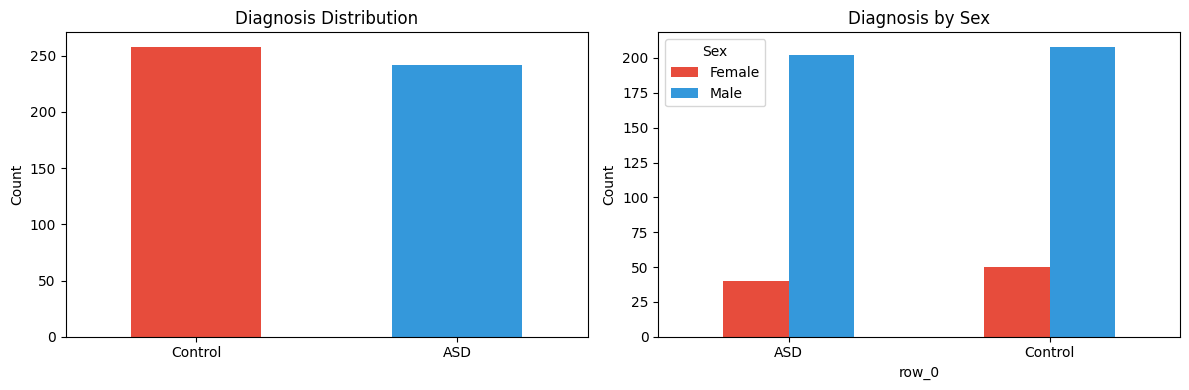

In [ ]:
# SOLUTION
print("Keys:", list(abide_dataset.keys()))

# Number of subjects
n_subjects = len(abide_dataset.rois_aal)
print(f"\nNumber of subjects downloaded: {n_subjects}")

# Shape of first subject's time-series
ts_first = abide_dataset.rois_aal[0]
print(f"\nShape of first subject's time-series: {ts_first.shape}")
print(f"  -> {ts_first.shape[0]} time points, {ts_first.shape[1]} brain regions (AAL atlas)")

# Phenotypic info
pheno_df = abide_dataset.phenotypic
print(f"\nPhenotypic columns: {list(pheno_df.columns)}")
print(f"\nDiagnosis distribution (DX_GROUP: 1=ASD, 2=TC):")
print(pheno_df['DX_GROUP'].value_counts())
print(f"\nSex distribution (SEX: 1=Male, 2=Female):")
print(pheno_df['SEX'].value_counts())


# Binary labels: 0=ASD, 1=TC
labels = (pheno_df['DX_GROUP'].values == 2).astype(int)  # 1=control, 0=ASD
sex = pheno_df['SEX'].values  # 1=Male, 2=Female

print(f"Labels shape: {labels.shape}")
print(f"ASD (0): {np.sum(labels == 0)}, Control (1): {np.sum(labels == 1)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Diagnosis distribution
diag_counts = pd.Series(labels).map({0: 'ASD', 1: 'Control'}).value_counts()
diag_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'])
axes[0].set_title('Diagnosis Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Diagnosis by sex
cross = pd.crosstab(
    pd.Series(labels).map({0: 'ASD', 1: 'Control'}),
    pd.Series(sex).map({1: 'Male', 2: 'Female'})
)
cross.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'])
axes[1].set_title('Diagnosis by Sex')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sex')

plt.tight_layout()
plt.show()

# Exercise 2: Computing Connectivity Matrices

Each subject has a time-series of shape `(T, 116)` (T time points measured across 116 AAL brain regions). To capture how regions interact, we compute a **functional connectivity matrix** (116×116) that summarises the statistical dependencies between all pairs of regions.

We will use **partial correlation** as our primary connectivity measure.



**Tasks:**
1. Compute the **partial** connectivity matrix for each subject using Nilearn's `ConnectivityMeasure`. As you should have checked already, you'll find the timeseries in `abide_dataset['rois_aal']`
3. Visualise the connectivity matrix for one ASD subject and one Control subject

In [ ]:
# ...


Connectivity matrices shape: (500, 116, 116)


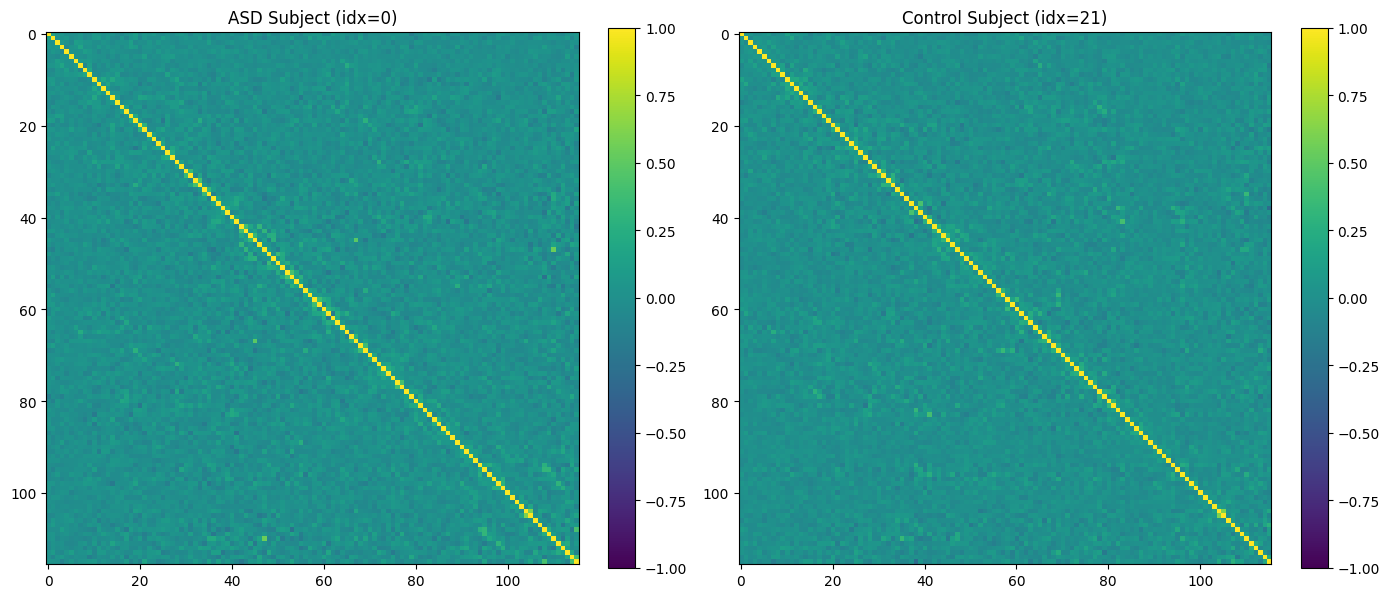

In [ ]:
# SOLUTION
corr_measure = ConnectivityMeasure(kind='partial correlation')
correlation_matrices = corr_measure.fit_transform(abide_dataset['rois_aal'])

print(f"\nConnectivity matrices shape: {correlation_matrices.shape}")

asd_idx = np.where(labels == 0)[0][0]
ctrl_idx = np.where(labels == 1)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(correlation_matrices[asd_idx], cmap='viridis', vmin=-1, vmax=1)
axes[0].set_title(f'ASD Subject (idx={asd_idx})')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(correlation_matrices[ctrl_idx], cmap='viridis', vmin=-1, vmax=1)
axes[1].set_title(f'Control Subject (idx={ctrl_idx})')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

The code below is computing the mean connectivity matrix for ASD and Control groups separately, and checking their difference.

What do you observe, is this difference higher or lower than what you were expecting? Notice that the colourbar range of the third plot is different.

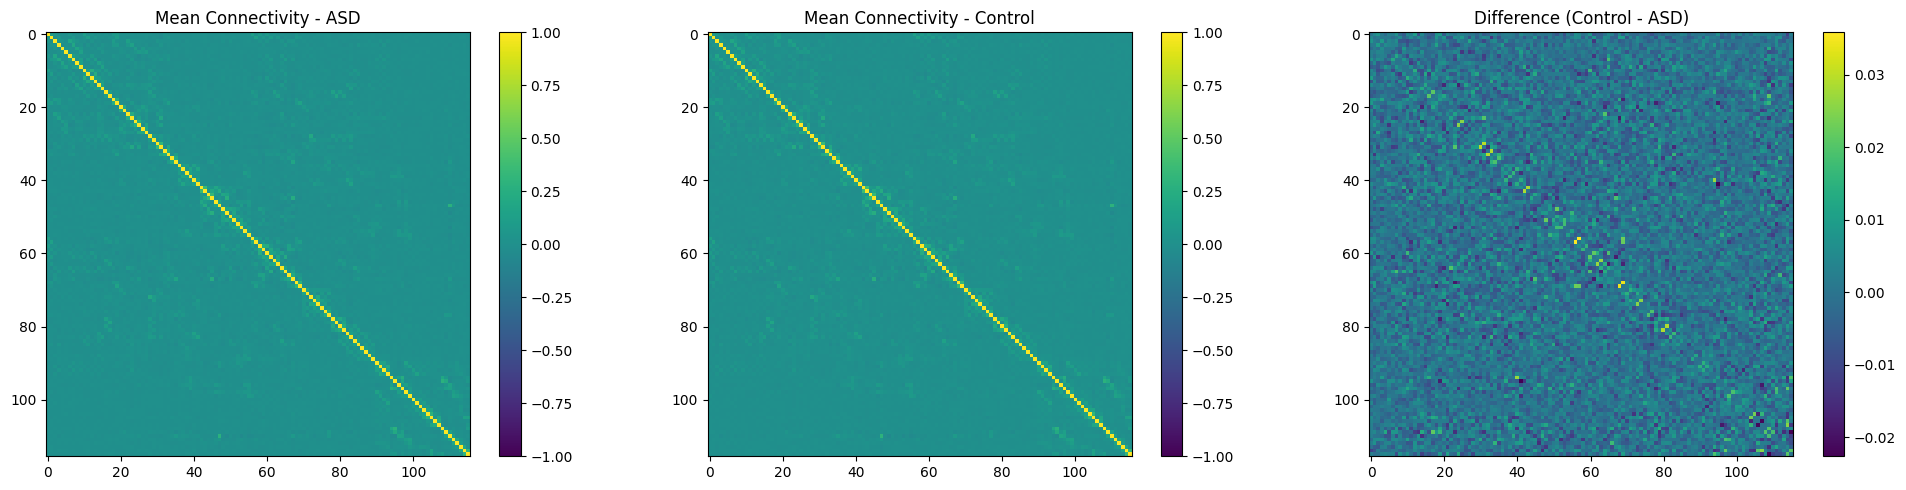

Max absolute difference: 0.0359
Mean absolute difference: 0.0040


In [ ]:
tmp_labels_array = (pheno_df['DX_GROUP'].values == 2).astype(int)  # 1=control, 0=ASD
tmp_sex_array = pheno_df['SEX'].values  # 1=Male, 2=Female

mean_asd = correlation_matrices[labels == 0].mean(axis=0)
mean_ctrl = correlation_matrices[labels == 1].mean(axis=0)
diff = mean_ctrl - mean_asd

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

im0 = axes[0].imshow(mean_asd, cmap='viridis', vmin=-1, vmax=1)
axes[0].set_title('Mean Connectivity - ASD')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(mean_ctrl, cmap='viridis', vmin=-1, vmax=1)
axes[1].set_title('Mean Connectivity - Control')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(diff, cmap='viridis')#, vmin=-2, vmax=2)
axes[2].set_title('Difference (Control - ASD)')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"Max absolute difference: {np.abs(diff).max():.4f}")
print(f"Mean absolute difference: {np.abs(diff).mean():.4f}")

# Exercise 3: Extracting the upper triangle features

For each connectivity matrix, extract the **upper triangle** (excluding the diagonal) as a flat feature vector, such that we can use later as a comparison with the GNN model.

Store all subjects' features in a 2D array `X_flat` of shape `(n_subjects, n_features)`


**Tip:**
 - Use `np.triu_indices(n_regions, k=1)` to get the indices of the upper triangle (k=1 excludes the diagonal).

In [ ]:
# ...

In [ ]:
# SOLUTION
n_regions = correlation_matrices.shape[1]
triu_idx = np.triu_indices(n_regions, k=1)

# Extract upper triangle for each subject
X_flat = np.array([cm[triu_idx] for cm in correlation_matrices])

print(f"Feature matrix shape: {X_flat.shape}")
print(f"\t{X_flat.shape[0]} subjects, {X_flat.shape[1]} features")
print(f"\t(116 * 115) / 2 = {116 * 115 // 2} unique pairs")

Feature matrix shape: (500, 6670)
	500 subjects, 6670 features
	(116 * 115) / 2 = 6670 unique pairs


# Exercise 4: Train / Validation / Test Splits

We will use a **75/15/10** (train/validation/test) splits, **stratified by both diagnosis AND sex**. This ensures each split has similar proportions of ASD/Control subjects and male/female subjects.

**Tasks:**
1. Create a combined stratification key from diagnosis label and sex (e.g., `"0_1"` for ASD male)
2. First split: separate out 10% as the **test** set
3. Second split: from the remaining 90%, take ~16.7% as **validation** (≈15% of total)
4. Print the sizes and class distributions for each split

**Tip:**
- Use `StratifiedShuffleSplit` from sklearn.


In [ ]:
# ...
# ..., test_idx = ...
# ...
# train_idx = ...
# val_idx = ...
# ...

In [ ]:
# SOLUTION
np.random.seed(42)

# Combined stratification key
strat_key = np.array([f"{l}_{s}" for l, s in zip(labels, sex)])

# First split: 90% train+val, 10% test
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
trainval_idx, test_idx = next(sss1.split(X_flat, strat_key))

# Second split: from trainval, take ~16.7% as validation (≈15% of total)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.167, random_state=42)
train_idx_rel, val_idx_rel = next(sss2.split(X_flat[trainval_idx], strat_key[trainval_idx]))

# Map relative indices back to original
train_idx = trainval_idx[train_idx_rel]
val_idx = trainval_idx[val_idx_rel]

print(f"Total subjects: {len(labels)}")
print(f"Train: {len(train_idx)} ({len(train_idx)/len(labels)*100:.1f}%)")
print(f"Val:   {len(val_idx)} ({len(val_idx)/len(labels)*100:.1f}%)")
print(f"Test:  {len(test_idx)} ({len(test_idx)/len(labels)*100:.1f}%)")

# Check distributions
for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    n_asd = np.sum(labels[idx] == 0)
    n_ctrl = np.sum(labels[idx] == 1)
    n_male = np.sum(sex[idx] == 1)
    n_female = np.sum(sex[idx] == 2)
    print(f"\n{name}: ASD={n_asd}, Ctrl={n_ctrl} | Male={n_male}, Female={n_female}")

Total subjects: 500
Train: 374 (74.8%)
Val:   76 (15.2%)
Test:  50 (10.0%)

Train: ASD=181, Ctrl=193 | Male=307, Female=67

Val: ASD=37, Ctrl=39 | Male=62, Female=14

Test: ASD=24, Ctrl=26 | Male=41, Female=9


# Exercise 5: Baseline SVM Classifier

A classic approach in neuroimaging is to flatten the upper triangle of the connectivity matrix (which you calculated already) and feed it to a traditional ML classifier. We use an **SVM with RBF kernel** as our baseline.

**Tasks:**
1. Create a scikit-learn pipeline with `StandardScaler` + `SVC` (use `kernel='rbf'`, `C=1.0`, `probability=True`)
2. Train on the training set
3. Evaluate on the **validation set** (accuracy, balanced accuracy, F1, AUC). If at the end of the notebook you have some time, you can use the validation set to decide on different hyperparameters.
4. Report final performance on the **test set**. Plot the confusion matrix for later analysis.

In [ ]:
# X_train, y_train = X_flat[train_idx], labels[train_idx]
# X_val, y_val = X_flat[val_idx], labels[val_idx]
# X_test, y_test = X_flat[test_idx], labels[test_idx]

# svm_pipeline = Pipeline([
#    ...

# ...

SVM Validation Performance
Accuracy:          0.5263
Balanced Accuracy: 0.5184
F1 Score:          0.6400
AUC-ROC:           0.5925

Classification Report:
              precision    recall  f1-score   support

         ASD       0.53      0.22      0.31        37
     Control       0.52      0.82      0.64        39

    accuracy                           0.53        76
   macro avg       0.53      0.52      0.47        76
weighted avg       0.53      0.53      0.48        76



SVM Test Performance
Accuracy:          0.6400
Balanced Accuracy: 0.6266
F1 Score:          0.7353
AUC-ROC:           0.7420


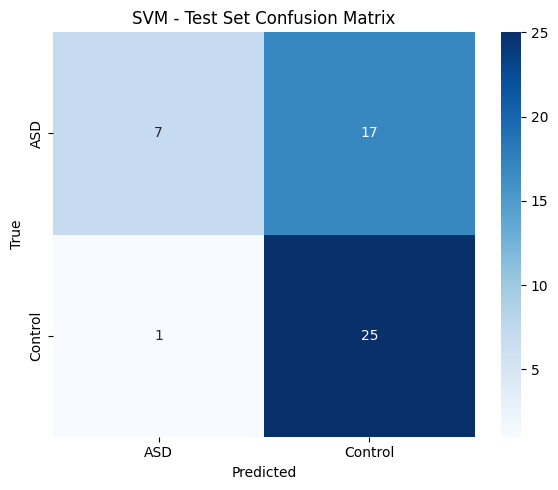

In [ ]:
# SOLUTION
X_train, y_train = X_flat[train_idx], labels[train_idx]
X_val, y_val = X_flat[val_idx], labels[val_idx]
X_test, y_test = X_flat[test_idx], labels[test_idx]


svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

# Train
svm_pipeline.fit(X_train, y_train)

# Evaluate on validation
y_val_pred = svm_pipeline.predict(X_val)
y_val_proba = svm_pipeline.predict_proba(X_val)[:, 1]

print("SVM Validation Performance")
print(f"Accuracy:          {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_val, y_val_pred):.4f}")
print(f"F1 Score:          {f1_score(y_val, y_val_pred):.4f}")
print(f"AUC-ROC:           {roc_auc_score(y_val, y_val_proba):.4f}")
print(f"\nClassification Report:\n{classification_report(y_val, y_val_pred, target_names=['ASD', 'Control'])}")

# Test set evaluation
y_test_pred_svm = svm_pipeline.predict(X_test)
y_test_proba_svm = svm_pipeline.predict_proba(X_test)[:, 1]

svm_test_acc = accuracy_score(y_test, y_test_pred_svm)
svm_test_bacc = balanced_accuracy_score(y_test, y_test_pred_svm)
svm_test_f1 = f1_score(y_test, y_test_pred_svm)
svm_test_auc = roc_auc_score(y_test, y_test_proba_svm)

print("\n")
print("SVM Test Performance")
print(f"Accuracy:          {svm_test_acc:.4f}")
print(f"Balanced Accuracy: {svm_test_bacc:.4f}")
print(f"F1 Score:          {svm_test_f1:.4f}")
print(f"AUC-ROC:           {svm_test_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred_svm)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ASD', 'Control'],
            yticklabels=['ASD', 'Control'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('SVM - Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

# Exercise 6: Graph Construction & GAT Model

Now for the exciting part! Instead of flattening the connectivity matrix, we treat each subject's brain as a **graph**:
- **Nodes** = brain regions (116 AAL regions)
- **Edges** = connections between regions (from the connectivity matrix)
- **Node features** = spatial coordinates of each region ins space (like positional encodings!)
- **Task** = graph-level binary classification (ASD vs Control)

We use the AAL atlas coordinates as node features. This is analogous to **positional encodings** in transformers. As we saw in class, we could choose different ways to create the graph.

For speed, we start with just the 3 spatial coordinates (x, y, z) from the AAL atlas as node features. However, keep in mind that these are identical across all subjects, meaning the model can only learn from differences in graph structure and edge weights. If you have time, try enriching the node features with subject-specific connectivity statistics (e.g., node strength, degree, mean and std of correlations per region), which will give the model a much stronger signal to distinguish ASD from controls.

I will give you the code to extract the AAL atlas coordinates and normalise them between [0, 1] to save you some time. Just so you understand, the coordinates represent the centre-of-mass of each brain region in a so called "MNI space" (x, y, z in mm). We normalise them so the GNN receives inputs in a consistent range.



> <u>**NOTE:**</u> The code below might give you an error when running `fetch_atlas_aal()`. If that happens to you, download the corresponding file directly from the link you see. Then, go to the Files on the left panel, and go to `root/nilearn_data/aal_SPM12`. Inside you'll see another folder whose name is composed with many numbers and letters. Just upload the file you downloaded to that folder, and execute the cell again.

In [ ]:
atlas = datasets.fetch_atlas_aal(version='SPM12')
coordinates = find_parcellation_cut_coords(labels_img=atlas['maps'])

print(f"Atlas regions: {len(atlas['labels'])} (there is an extra Background region)")
print(f"Coordinates shape: {coordinates.shape}")
print(f"First 5 regions: {atlas['labels'][:5]}")
print(f"First 5 coordinates:\n{coordinates[:5]}")

[fetch_atlas_aal] Dataset found in /root/nilearn_data/aal_SPM12

Atlas regions: 117 (there is an extra Background region)
Coordinates shape: (116, 3)
First 5 regions: ['Background', 'Precentral_L', 'Precentral_R', 'Frontal_Sup_L', 'Frontal_Sup_R']
First 5 coordinates:
[[-38.92822695  -6.96        49.64652482]
 [ 41.10085773  -9.54983733  50.80981958]
 [-18.79777159  33.4178273   40.99442897]
 [ 21.60483473  29.9097188   42.51307351]
 [-16.82450675  45.91900312 -14.71858775]]


In [ ]:
# Min-Max normalisation of coordinates
coord_min = coordinates.min(axis=0)
coord_max = coordinates.max(axis=0)
coords_normalised = (coordinates - coord_min) / (coord_max - coord_min)

print(f"Normalised coordinates shape: {coords_normalised.shape}")
print(f"Min per axis: {coords_normalised.min(axis=0)}")
print(f"Max per axis: {coords_normalised.max(axis=0)}")
print(f"\nFirst 5 normalised coordinates:\n{coords_normalised[:5]}")

# Convert to tensor (will be reused for all subjects)
node_features = torch.tensor(coords_normalised, dtype=torch.float32)
print(f"\nNode features tensor shape: {node_features.shape}")

Normalised coordinates shape: (116, 3)
Min per axis: [0. 0. 0.]
Max per axis: [1. 1. 1.]

First 5 normalised coordinates:
[[0.15106524 0.5704857  0.8383031 ]
 [0.85320388 0.55170051 0.84801187]
 [0.32768066 0.86336318 0.76609337]
 [0.68215468 0.83791738 0.77876786]
 [0.34499319 0.9540395  0.3011168 ]]

Node features tensor shape: torch.Size([116, 3])


## Exercise 6.1: Convert subjects to Pytorch Geometric graphs

**Tasks:**
1. For each subject, create a `torch_geometric.data.Data` object with:
   - `x`: node features (the normalised coordinates -same for all subjects)
   - `edge_index`: edges from the connectivity matrix (use a **threshold** to select edges, for example by keepin connections with |correlation| > 0.05)
   - `edge_attr`: edge weights (the correlation values for selected edges)
   - `y`: the subject's label
2. Store all graphs in a list
3. Print summary statistics about the graphs (mean number of edges, etc.)

**Tips:**
- Use `np.where(np.abs(matrix) > threshold)` to get edge indices
- `edge_index` in PyG expects shape `(2, num_edges)` as a `LongTensor` (COO format)

In [ ]:
# ...

# row, col = np.where(abs_corr > threshold)
# edge_index = torch.tensor(np.array([row, col]), dtype=torch.long)
# edge_weights = torch.tensor(
#    corr_matrix[row, col], dtype=torch.float32
# ).unsqueeze(1)  # shape (num_edges, 1)

# ...

In [ ]:
# SOLUTION
def create_graph(corr_matrix, label, base_node_feats, threshold=0.3):
    """
    Convert a correlation matrix into a PyG Data object
    with enriched, subject-specific node features.
    """
    n = corr_matrix.shape[0]

    # NODE FEATURES

    # Node strength: sum of absolute correlations per region
    abs_corr = np.abs(corr_matrix.copy())
    np.fill_diagonal(abs_corr, 0)
    node_strength = abs_corr.sum(axis=1)  # (116,)

    # Node degree: number of connections above threshold
    node_degree = (abs_corr > threshold).sum(axis=1).astype(float)  # (116,)

    # Mean connectivity per region
    np.fill_diagonal(corr_matrix, 0)
    node_mean_conn = corr_matrix.mean(axis=1)  # (116,)

    # Std of connectivity per region
    node_std_conn = corr_matrix.std(axis=1)  # (116,)

    # Stack into per-node feature vector
    subject_feats = np.column_stack([
        node_strength,
        node_degree,
        node_mean_conn,
        node_std_conn,
    ])  # (116, 4)

    # Normalise subject-specific features (per-subject z-score)
    feat_mean = subject_feats.mean(axis=0, keepdims=True)
    feat_std = subject_feats.std(axis=0, keepdims=True) + 1e-8
    subject_feats = (subject_feats - feat_mean) / feat_std

    # Concatenate with spatial coordinates: (116, 3) + (116, 4) = (116, 7)
    all_feats = np.concatenate([
        base_node_feats.numpy(),  # coordinates
        subject_feats
    ], axis=1)

    node_features = torch.tensor(all_feats, dtype=torch.float32)

    # EDGE (FEATURES)
    abs_corr2 = np.abs(corr_matrix.copy())
    np.fill_diagonal(abs_corr2, 0)
    row, col = np.where(abs_corr2 > threshold)

    edge_index = torch.tensor(np.array([row, col]), dtype=torch.long)
    edge_weights = torch.tensor(
        corr_matrix[row, col], dtype=torch.float32
    ).unsqueeze(1)

    data = Data(
        x=node_features,
        edge_index=edge_index,
        edge_attr=edge_weights,
        y=torch.tensor([label], dtype=torch.long)
    )
    return data

# Create graph dataset
THRESHOLD = 0.05
graph_list = []
for i in range(len(correlation_matrices)):
    g = create_graph(correlation_matrices[i], labels[i], node_features, threshold=THRESHOLD)
    graph_list.append(g)

print(f"Created {len(graph_list)} graphs")
print(f"\nExample graph: {graph_list[0]}")

# Summary statistics
n_edges = [g.edge_index.shape[1] for g in graph_list]
print(f"\nEdge statistics:")
print(f"  Mean edges:   {np.mean(n_edges):.0f}")
print(f"  Min edges:    {np.min(n_edges)}")
print(f"  Max edges:    {np.max(n_edges)}")
print(f"  Mean density: {np.mean(n_edges) / (116 * 115):.3f}")

Created 500 graphs

Example graph: Data(x=[116, 7], edge_index=[2, 5166], edge_attr=[5166, 1], y=[1])

Edge statistics:
  Mean edges:   4533
  Min edges:    342
  Max edges:    6324
  Mean density: 0.340


## Exercise 6.2: Create data loaders

**Tasks:**
1. Split the graph list into train/val/test using the same indices from before
2. Create PyG `DataLoader` objects with `batch_size=32`

In [ ]:
# ...

In [ ]:
# SOLUTION
train_graphs = [graph_list[i] for i in train_idx]
val_graphs = [graph_list[i] for i in val_idx]
test_graphs = [graph_list[i] for i in test_idx]

BATCH_SIZE = 32

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Quick check
batch = next(iter(train_loader))
print(f"\nExample batch: {batch}")
print(f"Batch x shape: {batch.x.shape}")
print(f"Batch edge_index shape: {batch.edge_index.shape}")
print(f"Batch y: {batch.y}")

Train batches: 12
Val batches:   3
Test batches:  2

Example batch: DataBatch(x=[3712, 7], edge_index=[2, 143296], edge_attr=[143296, 1], y=[32], batch=[3712], ptr=[33])
Batch x shape: torch.Size([3712, 7])
Batch edge_index shape: torch.Size([2, 143296])
Batch y: tensor([1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
        0, 1, 1, 1, 1, 0, 1, 0])


/tmp/ipykernel_2271/1499428431.py:8: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
/tmp/ipykernel_2271/1499428431.py:9: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
/tmp/ipykernel_2271/1499428431.py:10: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)


## Exercise 6.3: Define the GAT model

We will now define our Graph Attention Network (GAT). A GAT uses self-attention mechanisms to learn the importance of neighboring nodes for each node in the graph.

Our model will have:
1.  Two `GATConv` layers. The first layer will use multi-head attention.
2.  A `global_mean_pool` layer to aggregate node embeddings into a single graph-level embedding.
3.  A final linear layer for classification.

The single task you have here is to fill in the `__init__` and `forward` methods of the `BrainGAT` class.

In [ ]:
class BrainGAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.1):
        super(BrainGAT, self).__init__()
        ### YOUR CODE HERE ###
        self.dropout = None
        self.gat1 = None
        self.gat2 = None
        self.lin = None
        ### END YOUR CODE ###

    def forward(self, x, edge_index, batch, edge_attr=None):
        # First GAT layer
        # Set return_attention_weights=True to get the learned attention scores
        x, (edge_idx1, att_weights1) = self.gat1(x, edge_index, edge_attr=edge_attr, return_attention_weights=True)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Second GAT layer
        x, (edge_idx2, att_weights2) = self.gat2(x, edge_index, edge_attr=edge_attr, return_attention_weights=True)
        x = F.elu(x)

        # Readout layer
        x = global_mean_pool(x, batch)

        # Final classifier
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin(x)

        return x, (edge_idx1, att_weights1), (edge_idx2, att_weights2)

# Initialize the model
model = BrainGAT(
    in_channels=3, # x, y, z coordinates
    # in_channels=7 # 3 coordinates + 4 connectivity features in case you did that part
    hidden_channels=32,
    out_channels=2, # ASD vs Control
    heads=8,
    dropout=0
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

In [ ]:
# SOLUTION
class BrainGAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.1):
        super(BrainGAT, self).__init__()
        ### YOUR CODE HERE ###
        self.dropout = dropout
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout, edge_dim=1)
        self.gat2 = GATConv(hidden_channels * heads, hidden_channels, heads=1,
                            concat=False, dropout=dropout, edge_dim=1)
        self.lin = nn.Linear(hidden_channels, out_channels)
        ### END YOUR CODE ###

    def forward(self, x, edge_index, batch, edge_attr=None):
        # First GAT layer
        # Set return_attention_weights=True to get the learned attention scores
        x, (edge_idx1, att_weights1) = self.gat1(x, edge_index, edge_attr=edge_attr, return_attention_weights=True)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Second GAT layer
        x, (edge_idx2, att_weights2) = self.gat2(x, edge_index, edge_attr=edge_attr, return_attention_weights=True)
        x = F.elu(x)

        # Readout layer
        x = global_mean_pool(x, batch)

        # Final classifier
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin(x)

        return x, (edge_idx1, att_weights1), (edge_idx2, att_weights2)

# Initialize the model
model = BrainGAT(
    in_channels=7, # x, y, z coordinates
    hidden_channels=8,
    out_channels=2, # ASD vs Control
    heads=4,
    dropout=0.1
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

BrainGAT(
  (gat1): GATConv(7, 8, heads=4)
  (gat2): GATConv(32, 8, heads=1)
  (lin): Linear(in_features=8, out_features=2, bias=True)
)

Total parameters: 698


# Exercise 7: GAT Training

## Exercise 7.1: Training

**Tasks:**
1. Define an optimizer and loss function
2. Write a training loop for 100 epochs
3. Track training loss, validation loss, and validation accuracy at each epoch
4. Plot the training curves at the end

**Tips:**
- In the training loop: `for batch in train_loader: ...`
- Access `batch.x`, `batch.edge_index`, `batch.batch`, `batch.y`
- Use `model.eval()` and `torch.no_grad()` for validation
- Don't forget to save the best model based on the best validation loss

In [ ]:
# optimizer = torch.optim.Adam(...)
# criterion = nn.CrossEntropyLoss()

# ...

# if val_loss > best_val_loss:
#     best_val_loss = val_loss
#     best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

# ...

In [ ]:
# SOLUTION
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        out, _, _ = model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
        loss = criterion(out, batch.y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.num_graphs

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    for batch in loader:
        batch = batch.to(device)
        out, _, _ = model(batch.x, batch.edge_index, batch.batch, edge_attr=batch.edge_attr)
        loss = criterion(out, batch.y)

        total_loss += loss.item() * batch.num_graphs
        pred = out.argmax(dim=1)
        probs = F.softmax(out, dim=1)

        correct += (pred == batch.y).sum().item()
        total += batch.num_graphs
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

    return (
        total_loss / total,
        correct / total,
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs)
    )

In [ ]:
# SOLUTION
# Training loop
NUM_EPOCHS = 100

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_loss = 99999
best_model_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch  10 | Train Loss: 0.6898 | Train Acc: 0.5455 | Val Loss: 0.7064 | Val Acc: 0.4737
Epoch  20 | Train Loss: 0.6890 | Train Acc: 0.5428 | Val Loss: 0.7077 | Val Acc: 0.4868
Epoch  30 | Train Loss: 0.6862 | Train Acc: 0.5455 | Val Loss: 0.7081 | Val Acc: 0.4605
Epoch  40 | Train Loss: 0.6866 | Train Acc: 0.5321 | Val Loss: 0.7081 | Val Acc: 0.4737
Epoch  50 | Train Loss: 0.6887 | Train Acc: 0.5107 | Val Loss: 0.7090 | Val Acc: 0.4605
Epoch  60 | Train Loss: 0.6847 | Train Acc: 0.5508 | Val Loss: 0.7092 | Val Acc: 0.4211
Epoch  70 | Train Loss: 0.6871 | Train Acc: 0.5481 | Val Loss: 0.7096 | Val Acc: 0.4342
Epoch  80 | Train Loss: 0.6848 | Train Acc: 0.5535 | Val Loss: 0.7098 | Val Acc: 0.4079
Epoch  90 | Train Loss: 0.6846 | Train Acc: 0.5695 | Val Loss: 0.7101 | Val Acc: 0.4605
Epoch 100 | Train Loss: 0.6845 | Train Acc: 0.5642 | Val Loss: 0.7103 | Val Acc: 0.4605

Best validation loss: 0.7059


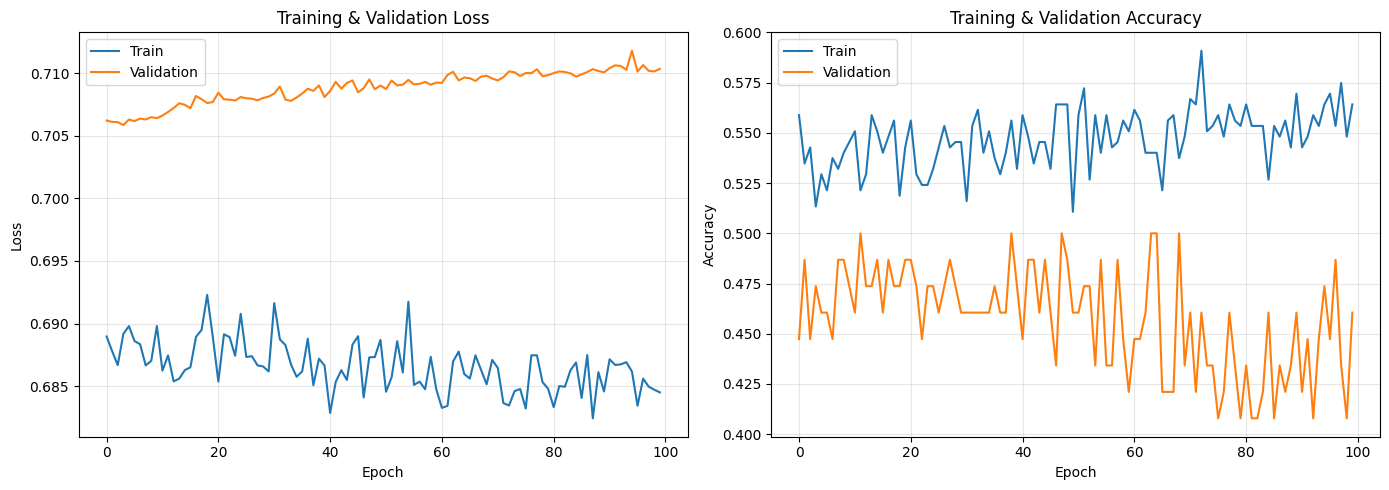

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exercise 7.2: Evaluate GAT on the test set

**Tasks:**
1. Load the best model weights
2. Evaluate on the test set
3. Report accuracy, balanced accuracy, F1, and AUC
4. Plot the confusion matrix

**Tip:**
 - Use `model.load_state_dict(best_model_state)` to load the best model.

In [ ]:
# ...

GAT Test Performance
Accuracy:          0.4600
Balanced Accuracy: 0.4439
F1 Score:          0.6197
AUC-ROC:           0.4984

Classification Report:
              precision    recall  f1-score   support

         ASD       0.20      0.04      0.07        24
     Control       0.49      0.85      0.62        26

    accuracy                           0.46        50
   macro avg       0.34      0.44      0.34        50
weighted avg       0.35      0.46      0.36        50



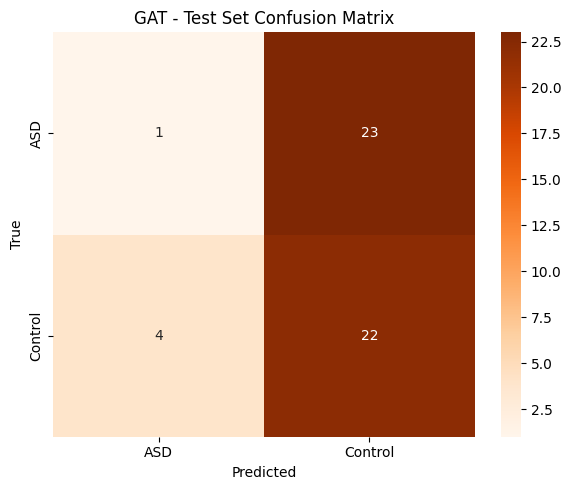

In [ ]:
# SOLUTION
# Load best model
model.load_state_dict(best_model_state)

# Evaluate on test
test_loss, test_acc, y_test_pred_gat, y_test_true_gat, y_test_proba_gat = evaluate(
    model, test_loader, criterion, device
)

gat_test_acc = accuracy_score(y_test_true_gat, y_test_pred_gat)
gat_test_bacc = balanced_accuracy_score(y_test_true_gat, y_test_pred_gat)
gat_test_f1 = f1_score(y_test_true_gat, y_test_pred_gat)
gat_test_auc = roc_auc_score(y_test_true_gat, y_test_proba_gat)

print("GAT Test Performance")
print(f"Accuracy:          {gat_test_acc:.4f}")
print(f"Balanced Accuracy: {gat_test_bacc:.4f}")
print(f"F1 Score:          {gat_test_f1:.4f}")
print(f"AUC-ROC:           {gat_test_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_true_gat, y_test_pred_gat, target_names=['ASD', 'Control']))

# Confusion matrix
cm_gat = confusion_matrix(y_test_true_gat, y_test_pred_gat)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_gat, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['ASD', 'Control'],
            yticklabels=['ASD', 'Control'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('GAT - Test Set Confusion Matrix')
plt.tight_layout()
plt.show()